Importing the dependencies


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

**Data Collection and processing**

In [2]:
# Load the dataset to pandas dataframe
data = pd.read_csv("/content/Rainfall.csv")
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [3]:
data.shape

(366, 12)

In [4]:
data.tail()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9
365,31,1026.4,20.5,17.8,15.5,13.0,74,66,no,5.7,20.0,23.3


In [5]:
data['day'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [7]:
data.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [8]:
# remove extra spaces in all columns
data.columns = data.columns.str.strip()

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temparature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    object 
 9   sunshine       366 non-null    float64
 10  winddirection  365 non-null    float64
 11  windspeed      365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [10]:
data = data.drop(columns=["day"])

In [11]:
data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [12]:
# Checking the number of missing values
data.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,1


In [13]:
data['winddirection'].unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [14]:
# Handle the missing values
data['winddirection'] = data['winddirection'].fillna(data['winddirection'].mode()[0])
data['windspeed'] = data['windspeed'].fillna(data['windspeed'].median())

In [15]:
data.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,0


In [16]:
data['rainfall'].unique()

array(['yes', 'no'], dtype=object)

In [17]:
data['rainfall'] = data['rainfall'].map({'yes':1, 'no':0})

In [18]:
data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


In [19]:
data.tail()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
361,1022.7,18.8,17.7,16.9,15.0,84,90,1,0.0,30.0,18.4
362,1026.6,18.6,17.3,16.3,12.8,75,85,1,1.0,20.0,25.9
363,1025.9,18.9,17.7,16.4,13.3,75,78,1,4.6,70.0,33.4
364,1025.3,19.2,17.3,15.2,13.3,78,86,1,1.2,20.0,20.9
365,1026.4,20.5,17.8,15.5,13.0,74,66,0,5.7,20.0,23.3


Exploratory Data Analysis

In [20]:
data.shape

(366, 11)

In [21]:
sns.set(style='darkgrid')

In [22]:
data.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.534153
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.056054
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


In [23]:
data.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

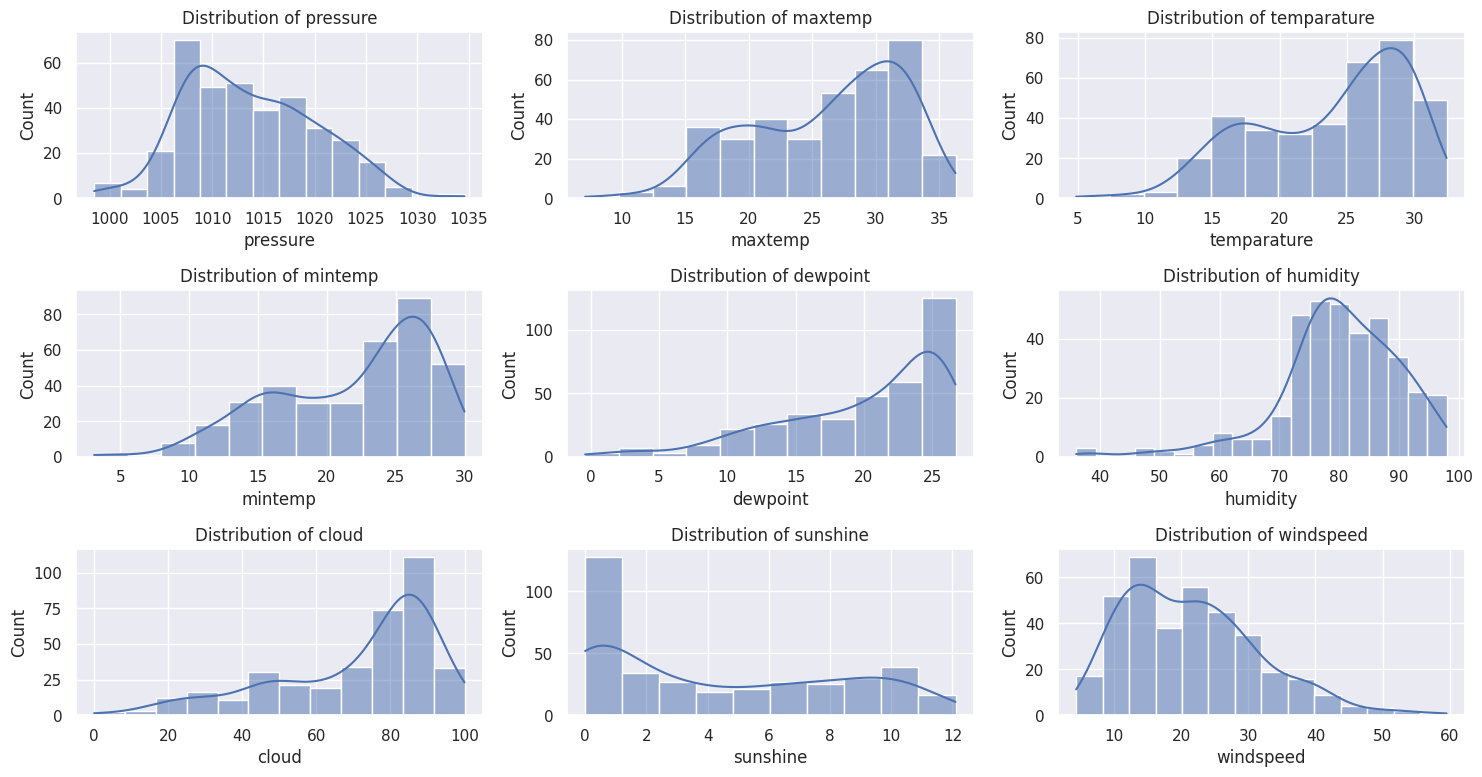

In [24]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(4, 3, i) # Changed from (3,3,i) to (4,3,i) to accommodate 10 plots
  sns.histplot(data[column], kde=True)
  plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

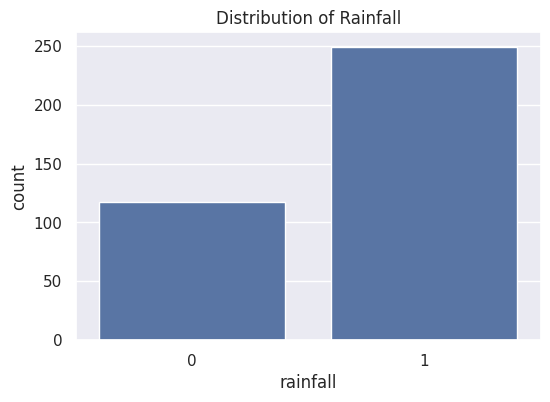

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='rainfall', data=data)
plt.title('Distribution of Rainfall')
plt.show()

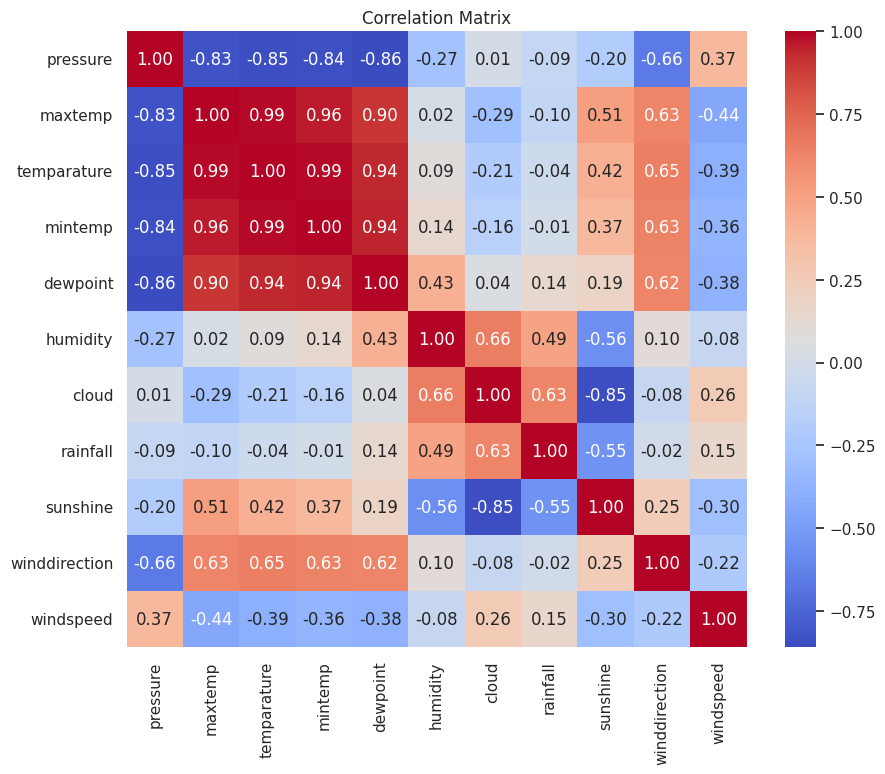

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

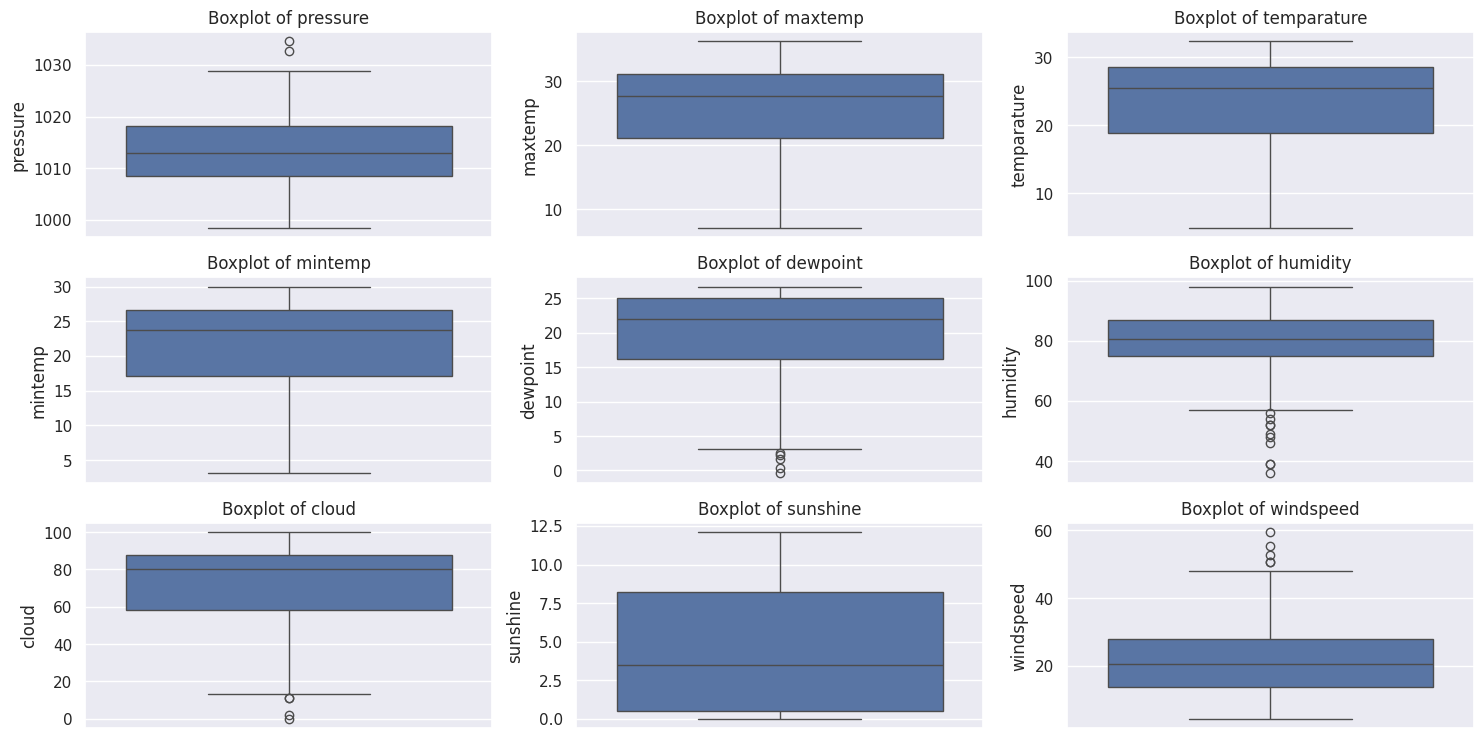

In [27]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(4, 3, i) # Changed from (3,3,i) to (4,3,i) to accommodate 10 plots
  sns.boxplot(data[column])
  plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

Data Preprocessing

In [28]:
data = data.drop(columns=['maxtemp', 'mintemp', 'dewpoint'])

In [29]:
data.head()

,pressure,temparature,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,18.3,72,49,1,9.3,80.0,26.3
1,1022.0,18.9,81,83,1,0.6,50.0,15.3
2,1019.7,19.3,95,91,1,0.0,40.0,14.2
3,1018.9,20.6,90,88,1,1.0,50.0,16.9
4,1015.9,20.7,95,81,1,0.0,40.0,13.7


In [30]:
data['rainfall'].value_counts()

,count
rainfall,
1,249
0,117


In [31]:
# Split features and target as X and y
X = data.drop(columns=['rainfall'])
y = data['rainfall']

In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority')
X_sm, y_sm = smote.fit_resample(X, y)

y_sm.value_counts()

,count
rainfall,
1,249
0,249


In [33]:
X

,pressure,temparature,humidity,cloud,sunshine,winddirection,windspeed
0,1025.9,18.3,72,49,9.3,80.0,26.3
1,1022.0,18.9,81,83,0.6,50.0,15.3
2,1019.7,19.3,95,91,0.0,40.0,14.2
3,1018.9,20.6,90,88,1.0,50.0,16.9
4,1015.9,20.7,95,81,0.0,40.0,13.7
...,...,...,...,...,...,...,...
361,1022.7,17.7,84,90,0.0,30.0,18.4
362,1026.6,17.3,75,85,1.0,20.0,25.9
363,1025.9,17.7,75,78,4.6,70.0,33.4
364,1025.3,17.3,78,86,1.2,20.0,20.9


In [34]:
y

,rainfall
0,1
1,1
2,1
3,1
4,1
...,...
361,1
362,1
363,1
364,1


In [35]:
# Splitting the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=15, stratify=y_sm)

Base model without hyerparameter tuning

In [36]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
rf_model.score(X_train, y_train)

1.0

In [38]:
y_pred = rf_model.predict(X_test)

In [39]:
accuracy_score(y_pred, y_test)

0.87

Hyper parameter tuned model

In [40]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [41]:
grid_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=50,
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [42]:
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, verbose=2)

In [43]:
best_rf_model = grid_search_rf.best_estimator_
print("Best Parameters:", grid_search_rf.best_params_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}


Model Evaluation

In [44]:
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

Cross-Validation Scores: [0.8125     0.875      0.8625     0.81012658 0.91139241]
Mean CV Score: 0.8543037974683543


In [45]:
# Test data
y_pred_best = best_rf_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

In [46]:
print(f"Accuracy Score on test data: {100 * accuracy_best:.2f}")

Accuracy Score on test data: 85.00


In [47]:
print('Classification Report:')
print(classification_report(y_test, y_pred_best))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        50
           1       0.84      0.86      0.85        50

    accuracy                           0.85       100
   macro avg       0.85      0.85      0.85       100
weighted avg       0.85      0.85      0.85       100



## XGBoost Classifier with Hyperparameter Tuning

In [48]:
from xgboost import XGBClassifier

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Initialize RandomizedSearchCV for XGBoost
grid_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=param_grid_xgb,
    n_iter=50,
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit RandomizedSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

# Get the best XGBoost model and its parameters
best_xgb_model = grid_search_xgb.best_estimator_
print("Best Parameters for XGBoost:", grid_search_xgb.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters for XGBoost: {'subsample': 1.0, 'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:47:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## XGBoost Model Evaluation

In [49]:
# Evaluate the best XGBoost model using cross-validation
cv_scores_xgb = cross_val_score(best_xgb_model, X_train, y_train, cv=5)
print("XGBoost Cross-Validation Scores:", cv_scores_xgb)
print("Mean XGBoost CV Score:", np.mean(cv_scores_xgb))

# Make predictions on the test set
y_pred_xgb = best_xgb_model.predict(X_test)

# Calculate accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy Score on test data (XGBoost): {100 * accuracy_xgb:.2f}")

# Print classification report
print('\nXGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:47:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:47:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:47:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:47:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost Cross-Validation Scores: [0.8        0.85       0.825      0.83544304 0.88607595]
Mean XGBoost CV Score: 0.8393037974683544
Accuracy Score on test data (XGBoost): 82.00

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.81        50
           1       0.80      0.86      0.83        50

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



## Model Comparison and Selection

In [50]:
print(f"Random Forest Test Accuracy: {100 * accuracy_best:.2f}")
print(f"XGBoost Test Accuracy: {100 * accuracy_xgb:.2f}")

if accuracy_xgb > accuracy_best:
    print("\nXGBoost is the better model based on test accuracy.")
    final_model = best_xgb_model
    final_model_name = "XGBoost Classifier"
else:
    print("\nRandom Forest is the better model based on test accuracy.")
    final_model = best_rf_model
    final_model_name = "Random Forest Classifier"

print(f"Selected Best Model: {final_model_name}")

Random Forest Test Accuracy: 85.00
XGBoost Test Accuracy: 82.00

Random Forest is the better model based on test accuracy.
Selected Best Model: Random Forest Classifier


In [51]:
X_train.head()

,pressure,temparature,humidity,cloud,sunshine,winddirection,windspeed
233,1002.200000,30.000000,77,70,7.700000,350.000000,13.600000
271,1006.700000,29.000000,61,30,11.100000,10.000000,16.400000
214,1011.600000,28.900000,78,54,11.400000,100.000000,9.800000
50,1023.200000,16.000000,67,55,5.900000,20.000000,23.900000
418,1020.847003,16.476738,55,27,10.188249,37.649873,18.046046


In [52]:
X_train.columns

Index(['pressure', 'temparature', 'humidity', 'cloud', 'sunshine',
       'winddirection', 'windspeed'],
      dtype='object')

In [53]:
input_data = (1015.9, 19.9, 95, 81, 0.0, 40.0, 13.7)
input_df = pd.DataFrame([input_data], columns=['pressure', 'temparature', 'humidity', 'cloud', 'sunshine',
       'winddirection', 'windspeed'])
prediction = best_rf_model.predict(input_df)
print(prediction)

[1]


In [54]:
# Save models and feaure names to a pickle file
model_data = {'model': best_rf_model, 'feautres_name': X.columns.tolist()}

In [55]:
with open('Rainfall_Prediction_model.pkl', 'wb') as model_file:
    pickle.dump(model_data, model_file)